# 0.5.8 — What Do the Bottom 3 (by Profit $) Have in Common?

Central Asia, Canada, Southern Africa. Part of [`0.5_by_region_analysis.ipynb`](0.5_by_region_analysis.ipynb) — deep dives on each individually live in [`0.5.4`](0.5.4_deepdive_central_asia.ipynb), [`0.5.5`](0.5.5_deepdive_canada.ipynb), [`0.5.6`](0.5.6_deepdive_southern_africa.ipynb).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

CATEGORICAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
BLUE, ORANGE = CATEGORICAL[0], CATEGORICAL[1]
POS, NEG = '#2a78d6', '#e34948'
INK = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRID = '#e1e0d9'
SURFACE = '#fcfcfb'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'axes.edgecolor': GRID,
    'axes.labelcolor': INK_SECONDARY, 'text.color': INK,
    'xtick.color': INK_MUTED, 'ytick.color': INK_MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
    'font.size': 10,
})

def style_axis(ax, x_grid=False, y_grid=True):
    if x_grid: ax.grid(axis='x', zorder=0)
    if y_grid: ax.grid(axis='y', zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)

def usd(x, pos=None):
    if abs(x) >= 1000:
        return f"${x:,.0f}"
    return f"${x:,.1f}"

USD_FMT = mticker.FuncFormatter(usd)
DATA_DIR = '.'

In [2]:
df_full = pd.read_csv(f'{DATA_DIR}/DataCoSupplyChainDataset.csv', encoding='latin1')
df_full['order date (DateOrders)'] = pd.to_datetime(df_full['order date (DateOrders)'])
df_full['month'] = df_full['order date (DateOrders)'].dt.to_period('M')

df = df_full[df_full['order date (DateOrders)'] < '2017-10-01'].copy()  # exclude Nov-2017+ order-composition artifact (0.1)
print(f"excluded {len(df_full) - len(df):,} rows from Oct 2017 onward ({(len(df_full)-len(df))/len(df_full)*100:.1f}% of {len(df_full):,})")

TOTAL_PROFIT = df['Order Profit Per Order'].sum()
TOTAL_REVENUE = df['Order Item Total'].sum()

def region_row(region):
    sub = df[df['Order Region'] == region]
    profit = sub['Order Profit Per Order'].sum()
    revenue = sub['Order Item Total'].sum()
    return sub, profit, revenue

_all = df.groupby('Order Region').agg(revenue=('Order Item Total', 'sum'), profit=('Order Profit Per Order', 'sum'),
                                       n=('Order Id', 'size')).reset_index()
_all['margin_pct'] = _all['profit'] / _all['revenue'] * 100
_all['margin_rank'] = _all['margin_pct'].rank(ascending=False).astype(int)
_all['profit_rank'] = _all['profit'].rank(ascending=False).astype(int)
_all['pct_of_company_profit'] = _all['profit'] / TOTAL_PROFIT * 100
RANKS = _all.set_index('Order Region')

print(f"transactions: {df.shape[0]:,} rows across {df['Order Region'].nunique()} regions")
print(f"company total: revenue {usd(TOTAL_REVENUE)}, profit {usd(TOTAL_PROFIT)}")

excluded 8,557 rows from Oct 2017 onward (4.7% of 180,519)
transactions: 171,962 rows across 23 regions
company total: revenue $30,774,234, profit $3,685,985


**Data-generation artifact excluded from here on**: rows from Oct 2017 onward are dropped before any revenue/profit/margin figure below is computed — that window is where order composition breaks (`0.1_company_growth.ipynb` §2: every order collapses to 1 line item, order counts and per-order revenue become non-comparable to earlier months). This affects Western Europe, Northern Europe and Southern Europe's *totals* slightly (they're the only ones of the 6 regions here with any activity that late); it has zero effect on Central America, South America, Central Asia, Canada or Southern Africa, whose data ends earlier anyway. `TOTAL_PROFIT`/`TOTAL_REVENUE` (and therefore every `pct_of_company_profit` figure below) are computed on this same excluded basis, company-wide.

## Side-by-side

In [3]:
BOT3 = ['Central Asia', 'Canada', 'Southern Africa']
market_map = df.drop_duplicates('Order Region').set_index('Order Region')['Market']
discount = df.groupby('Order Region')['Order Item Discount Rate'].mean()
late = df.groupby('Order Region')['Late_delivery_risk'].mean()
months_active = df.groupby('Order Region')['month'].nunique()

b = RANKS.loc[BOT3, ['profit', 'revenue', 'margin_pct', 'margin_rank', 'profit_rank', 'n', 'pct_of_company_profit']].copy()
b['market'] = market_map.loc[BOT3]
b['avg_discount'] = discount.loc[BOT3]
b['late_risk'] = late.loc[BOT3]
b['months_with_orders'] = months_active.loc[BOT3]
b.round(3)

,profit,revenue,margin_pct,margin_rank,profit_rank,n,pct_of_company_profit,market,avg_discount,late_risk,months_with_orders
Order Region,,,,,,,,,,,
Central Asia,13045.28,97953.691,13.318,3,23,553,0.354,Pacific Asia,0.106,0.553,6
Canada,23900.71,168257.422,14.205,2,22,959,0.648,USCA,0.102,0.488,6
Southern Africa,30826.05,204302.522,15.088,1,21,1157,0.836,Africa,0.103,0.533,6


In [4]:
combined_profit = b['profit'].sum()
print(f"Combined profit of all 3: {usd(combined_profit)} = {combined_profit/TOTAL_PROFIT*100:.2f}% of company profit")
we_profit = RANKS.loc['Western Europe', 'profit']
print(f"For comparison, Western Europe alone generates {usd(we_profit)} ({RANKS.loc['Western Europe','pct_of_company_profit']:.2f}% of company profit) -- {we_profit/combined_profit:.1f}x the whole bottom-3 group combined")

Combined profit of all 3: $67,772 = 1.84% of company profit
For comparison, Western Europe alone generates $551,027 (14.95% of company profit) -- 8.1x the whole bottom-3 group combined


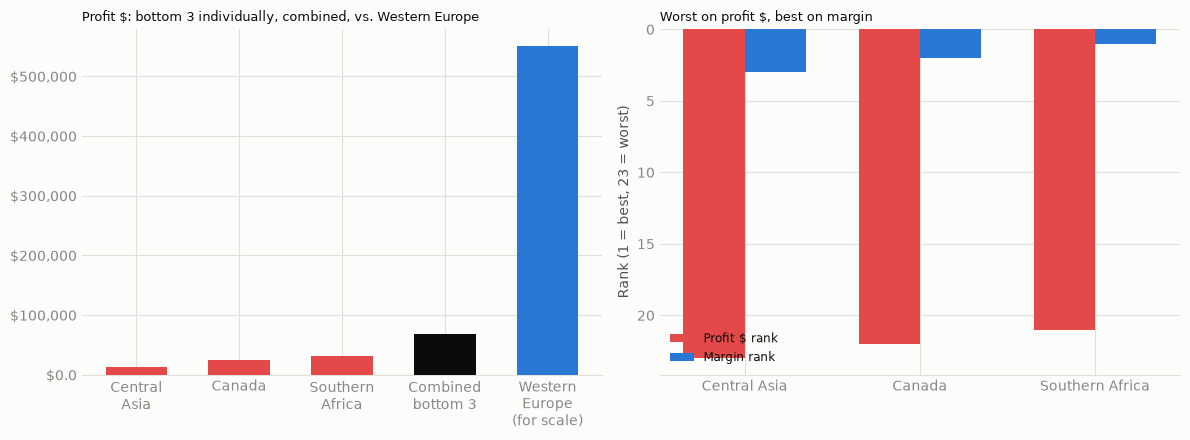

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(['Central\nAsia', 'Canada', 'Southern\nAfrica', 'Combined\nbottom 3', 'Western\nEurope\n(for scale)'],
            [b.loc['Central Asia', 'profit'], b.loc['Canada', 'profit'], b.loc['Southern Africa', 'profit'], combined_profit, RANKS.loc['Western Europe', 'profit']],
            color=[NEG, NEG, NEG, INK, BLUE], zorder=3, width=0.6)
axes[0].yaxis.set_major_formatter(USD_FMT)
axes[0].set_title('Profit $: bottom 3 individually, combined, vs. Western Europe', loc='left', fontsize=9, color=INK)
style_axis(axes[0], y_grid=True)

x = np.arange(3)
w = 0.35
axes[1].bar(x - w/2, b['profit_rank'], width=w, color=NEG, label='Profit $ rank', zorder=3)
axes[1].bar(x + w/2, b['margin_rank'], width=w, color=BLUE, label='Margin rank', zorder=3)
axes[1].set_xticks(x); axes[1].set_xticklabels(b.index)
axes[1].set_ylabel('Rank (1 = best, 23 = worst)')
axes[1].invert_yaxis()
axes[1].legend(frameon=False, fontsize=8.5)
axes[1].set_title('Worst on profit $, best on margin', loc='left', fontsize=9, color=INK)
style_axis(axes[1], y_grid=True)

plt.tight_layout()
plt.show()

## What they share

- **They're the 3 smallest regions in the company by order volume** — 553, 959, 1,157 lines — and by revenue ($98K – $204K each).
- **They're also, not coincidentally, the 3 *best* margin regions in the company** (13.3% – 15.1%). Small samples swing further in both directions; these three got lucky on the margin axis precisely because there are so few orders to average over.
- **All 3 sit in the same short ~143-day active window** (Aug 2016 – Jan 2017), with no order-flow gaps — the flip side of being small is that there's no room for a multi-month dead zone to hide in.
- **No real loss problem anywhere** — a handful of trivial negative categories (all under $120), nothing like Western Europe's -$1,396 Basketball line or a genuine loss month.
- **Combined, they generate $67.8K — 1.8% of company profit.** Western Europe alone generates over 8x that amount.

## Bottom line

There's no operational fix to chase here — no bad month, no loss-making category, no delivery or discount issue. These three are simply too small to matter in a profit-dollar conversation, and their high margins are a statistical artifact of that size rather than a strategy worth exporting elsewhere. If time in the room is limited, this is the group to spend the least of it on.